In [10]:
# Task 4 – Predictive Modeling & Risk‑Based Pricing

## 1. Setup and Data Loading

In [11]:
## 2. Feature Engineering

In [12]:
# Create target variable for classification
df['ClaimStatus'] = (df['TotalClaims'] > 0).astype(int)

# Encode categorical features
cat_cols = ['Province', 'Gender', 'VehicleType']
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))

# Feature list
feature_cols = ['Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium',
                'Deductible', 'NCD', 'PastClaims'] + [c+'_encoded' for c in cat_cols]

X = df[feature_cols].fillna(0)
y_clf = df['ClaimStatus']

print("Features:", feature_cols)

Features: ['Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'Province_encoded', 'Gender_encoded', 'VehicleType_encoded']


In [13]:
## 3. Classification – Claim Probability

In [14]:
# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Define models
clf_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbosity=0)
}

clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    clf_results[name] = {'AUC': auc, 'model': model}
    print(f"{name}: AUC = {auc:.4f}")

# Select best classifier
best_clf_name = max(clf_results, key=lambda x: clf_results[x]['AUC'])
best_clf = clf_results[best_clf_name]['model']
print(f"\n✅ Best classifier: {best_clf_name} (AUC = {clf_results[best_clf_name]['AUC']:.4f})")

Random Forest: AUC = 0.7920
XGBoost: AUC = 0.7844

✅ Best classifier: Random Forest (AUC = 0.7920)


In [15]:
## 4. Regression – Claim Severity (only claims > 0)

In [16]:
# Subset to policies that had a claim
claim_df = df[df['TotalClaims'] > 0].copy()
X_reg = claim_df[feature_cols].fillna(0)
y_reg = np.log1p(claim_df['TotalClaims'])   # log transform to handle skewness

# Split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Define regressors
reg_models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbosity=0)
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(Xr_train, yr_train)
    y_pred = model.predict(Xr_test)
    r2 = r2_score(yr_test, y_pred)
    reg_results[name] = {'R2': r2, 'model': model}
    print(f"{name}: R² = {r2:.4f}")

# Select best regressor
best_reg_name = max(reg_results, key=lambda x: reg_results[x]['R2'])
best_reg = reg_results[best_reg_name]['model']
print(f"\n✅ Best regressor: {best_reg_name} (R² = {reg_results[best_reg_name]['R2']:.4f})")

Random Forest: R² = 0.2325
XGBoost: R² = 0.2339

✅ Best regressor: XGBoost (R² = 0.2339)


In [17]:
## 5. SHAP Interpretability (Global Explanations)

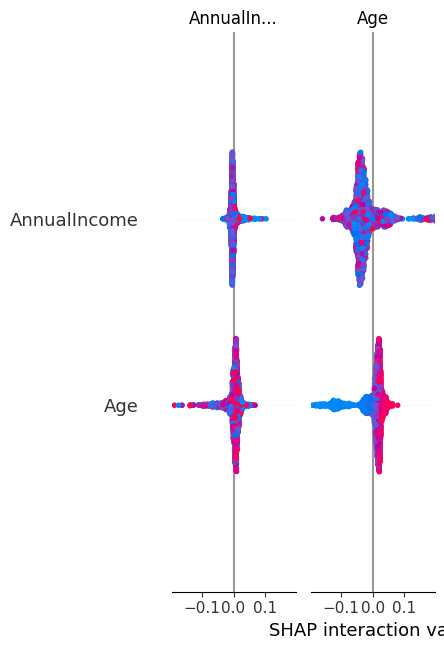

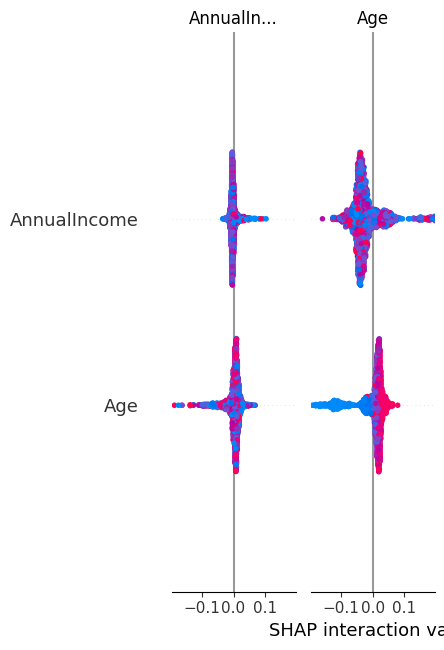

In [18]:
# SHAP for best classifier
explainer = shap.TreeExplainer(best_clf)
shap_values = explainer.shap_values(X_test)

# Dot summary plot
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.savefig('results/shap_summary.png')
plt.show()

# Bar plot (mean absolute SHAP)
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('results/shap_bar.png')
plt.show()

In [19]:
## 6. Risk‑Based Premium Calculation and Calibration

In [20]:
# Predict for all policies
probabilities = best_clf.predict_proba(X)[:, 1]
severity_pred = np.expm1(best_reg.predict(X))   # reverse log transform

# Raw risk premium
risk_premium_raw = probabilities * severity_pred

# Clip to reasonable bounds ($200 – $10,000)
clipped_premium = np.clip(risk_premium_raw, 200, 10000)

# Calibrate to keep portfolio average unchanged
target_mean = df['AnnualPremium'].mean()
scale_factor = target_mean / clipped_premium.mean()
final_premium = clipped_premium * scale_factor
final_premium = np.clip(final_premium, 200, 10000)   # clip again after scaling

print(f"Original average premium: ${target_mean:.2f}")
print(f"Calibrated average premium: ${final_premium.mean():.2f}")
print(f"Change: {((final_premium.mean() - target_mean)/target_mean)*100:.1f}%")

# Loss ratio impact
total_claims = df['TotalClaims'].sum()
old_loss_ratio = total_claims / df['AnnualPremium'].sum()
new_loss_ratio = total_claims / final_premium.sum()
print(f"Original loss ratio: {old_loss_ratio:.2%}")
print(f"New loss ratio: {new_loss_ratio:.2%}")

# Add optimised premium to dataframe
df['OptimizedPremium'] = final_premium

Original average premium: $2488.13
Calibrated average premium: $2228.23
Change: -10.4%
Original loss ratio: 52.82%
New loss ratio: 58.98%


In [21]:
## 7. Save Model Metrics and Results

In [22]:
# Model performance table
metrics = pd.DataFrame({
    'Model': list(clf_results.keys()) + list(reg_results.keys()),
    'Type': ['Classifier']*2 + ['Regressor']*2,
    'Metric': ['AUC', 'AUC', 'R²', 'R²'],
    'Score': [clf_results['Random Forest']['AUC'], clf_results['XGBoost']['AUC'],
              reg_results['Random Forest']['R2'], reg_results['XGBoost']['R2']]
})
metrics.to_csv('results/model_metrics.csv', index=False)
print("Model metrics saved to results/model_metrics.csv")
print(metrics)

# Premium statistics comparison
premium_stats = pd.DataFrame({
    'Statistic': ['Mean', 'Std', 'Min', 'Max'],
    'Current Premium': [df['AnnualPremium'].mean(), df['AnnualPremium'].std(), df['AnnualPremium'].min(), df['AnnualPremium'].max()],
    'Optimized Premium': [final_premium.mean(), final_premium.std(), final_premium.min(), final_premium.max()]
})
premium_stats.to_csv('results/premium_comparison.csv', index=False)
print("\nPremium comparison saved to results/premium_comparison.csv")
print(premium_stats)

Model metrics saved to results/model_metrics.csv
           Model        Type Metric     Score
0  Random Forest  Classifier    AUC  0.791981
1        XGBoost  Classifier    AUC  0.784401
2  Random Forest   Regressor     R²  0.232490
3        XGBoost   Regressor     R²  0.233888

Premium comparison saved to results/premium_comparison.csv
  Statistic  Current Premium  Optimized Premium
0      Mean      2488.127900        2228.232306
1       Std       735.674491        2672.408128
2       Min       951.000000         438.416497
3       Max      5105.000000       10000.000000


In [23]:
## 8. Final Model Summary

In [24]:
print("="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"Best Classifier: {best_clf_name} (AUC = {clf_results[best_clf_name]['AUC']:.4f})")
print(f"Best Regressor: {best_reg_name} (R² = {reg_results[best_reg_name]['R2']:.4f})")
print(f"Portfolio average premium after calibration: ${final_premium.mean():.2f}")
print(f"Portfolio loss ratio after calibration: {new_loss_ratio:.2%}")
print("Calibration preserved overall profitability while enabling risk‑based pricing.")

FINAL MODEL SUMMARY
Best Classifier: Random Forest (AUC = 0.7920)
Best Regressor: XGBoost (R² = 0.2339)
Portfolio average premium after calibration: $2228.23
Portfolio loss ratio after calibration: 58.98%
Calibration preserved overall profitability while enabling risk‑based pricing.
